In [53]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, plot_ccf


pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

(23673, 9)


,datetime,price,precipitation,cloud_cover,temperature,relative_humidity,renewable_share_of_load,load,sum_cbet
26304,2022-01-01 00:00:00+00:00,41.33,0.025,87.50,11.425,85.50,86.5,41177.8,-8.397
26305,2022-01-01 01:00:00+00:00,43.22,0.025,100.00,11.225,86.25,86.3,39669.8,-6.700
26306,2022-01-01 02:00:00+00:00,45.46,0.100,100.00,11.100,86.00,83.4,39448.7,-5.457
26307,2022-01-01 03:00:00+00:00,37.67,0.000,96.75,10.850,86.50,80.0,39112.1,-4.827
26308,2022-01-01 04:00:00+00:00,39.70,0.000,100.00,10.775,86.00,78.7,38358.2,-4.569


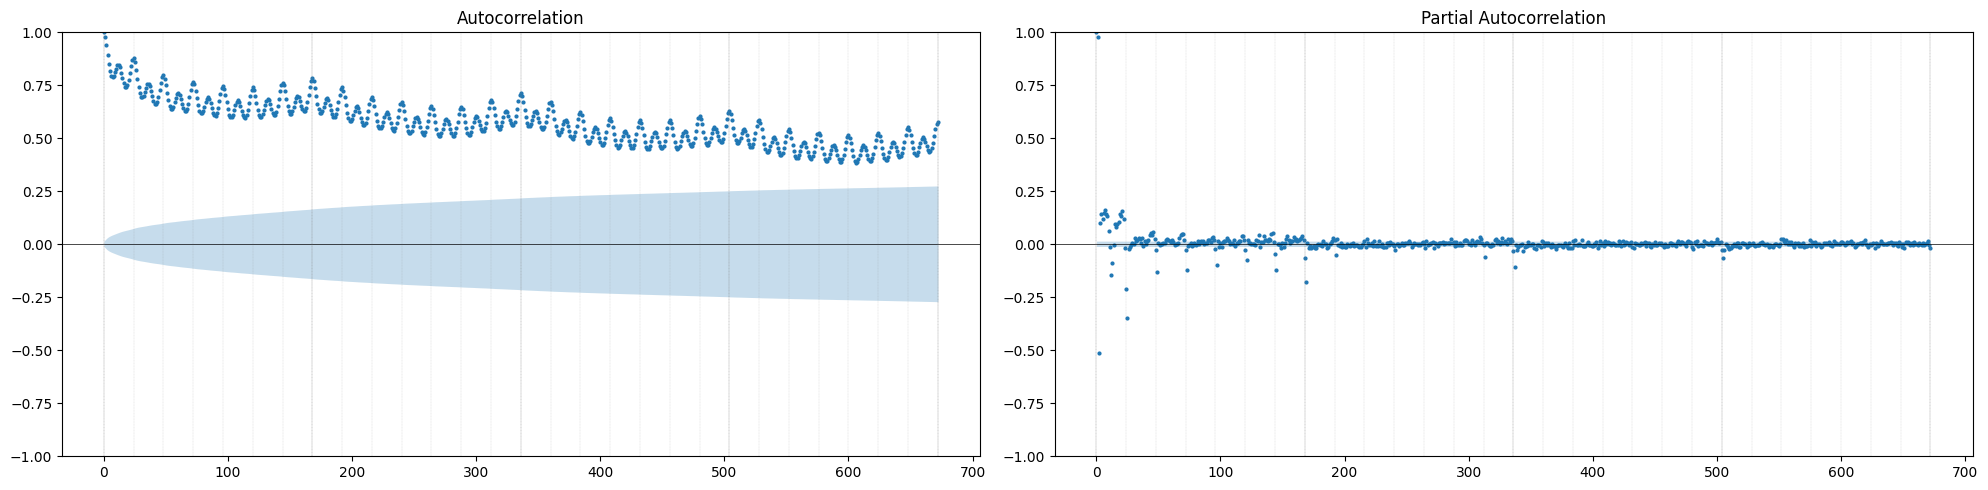

In [62]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(20, 5))

plot_acf(x=train_data['price'], ax=ax0, lags=24*7*4, use_vlines=False, markersize=2)
ax0.axhline(0, color='black', linewidth=0.5)
ax0.vlines([_ for _ in range(0, 24*7*4+1, 24)], ymin=-1, ymax=1, color='gray', linewidth=0.2, linestyle=':')
ax0.vlines([_ for _ in range(0, 24*7*4+1, 24*7)], ymin=-1, ymax=1, color='gray', linewidth=0.2, linestyle='--')

plot_pacf(x=train_data['price'], ax=ax1, lags=24*7*4, use_vlines=False, markersize=2)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.vlines([_ for _ in range(0, 24*7*4+1, 24)], ymin=-1, ymax=1, color='gray', linewidth=0.2, linestyle=':')
ax1.vlines([_ for _ in range(0, 24*7*4+1, 24*7)], ymin=-1, ymax=1, color='gray', linewidth=0.2, linestyle='--')

fig.tight_layout()
plt.show()

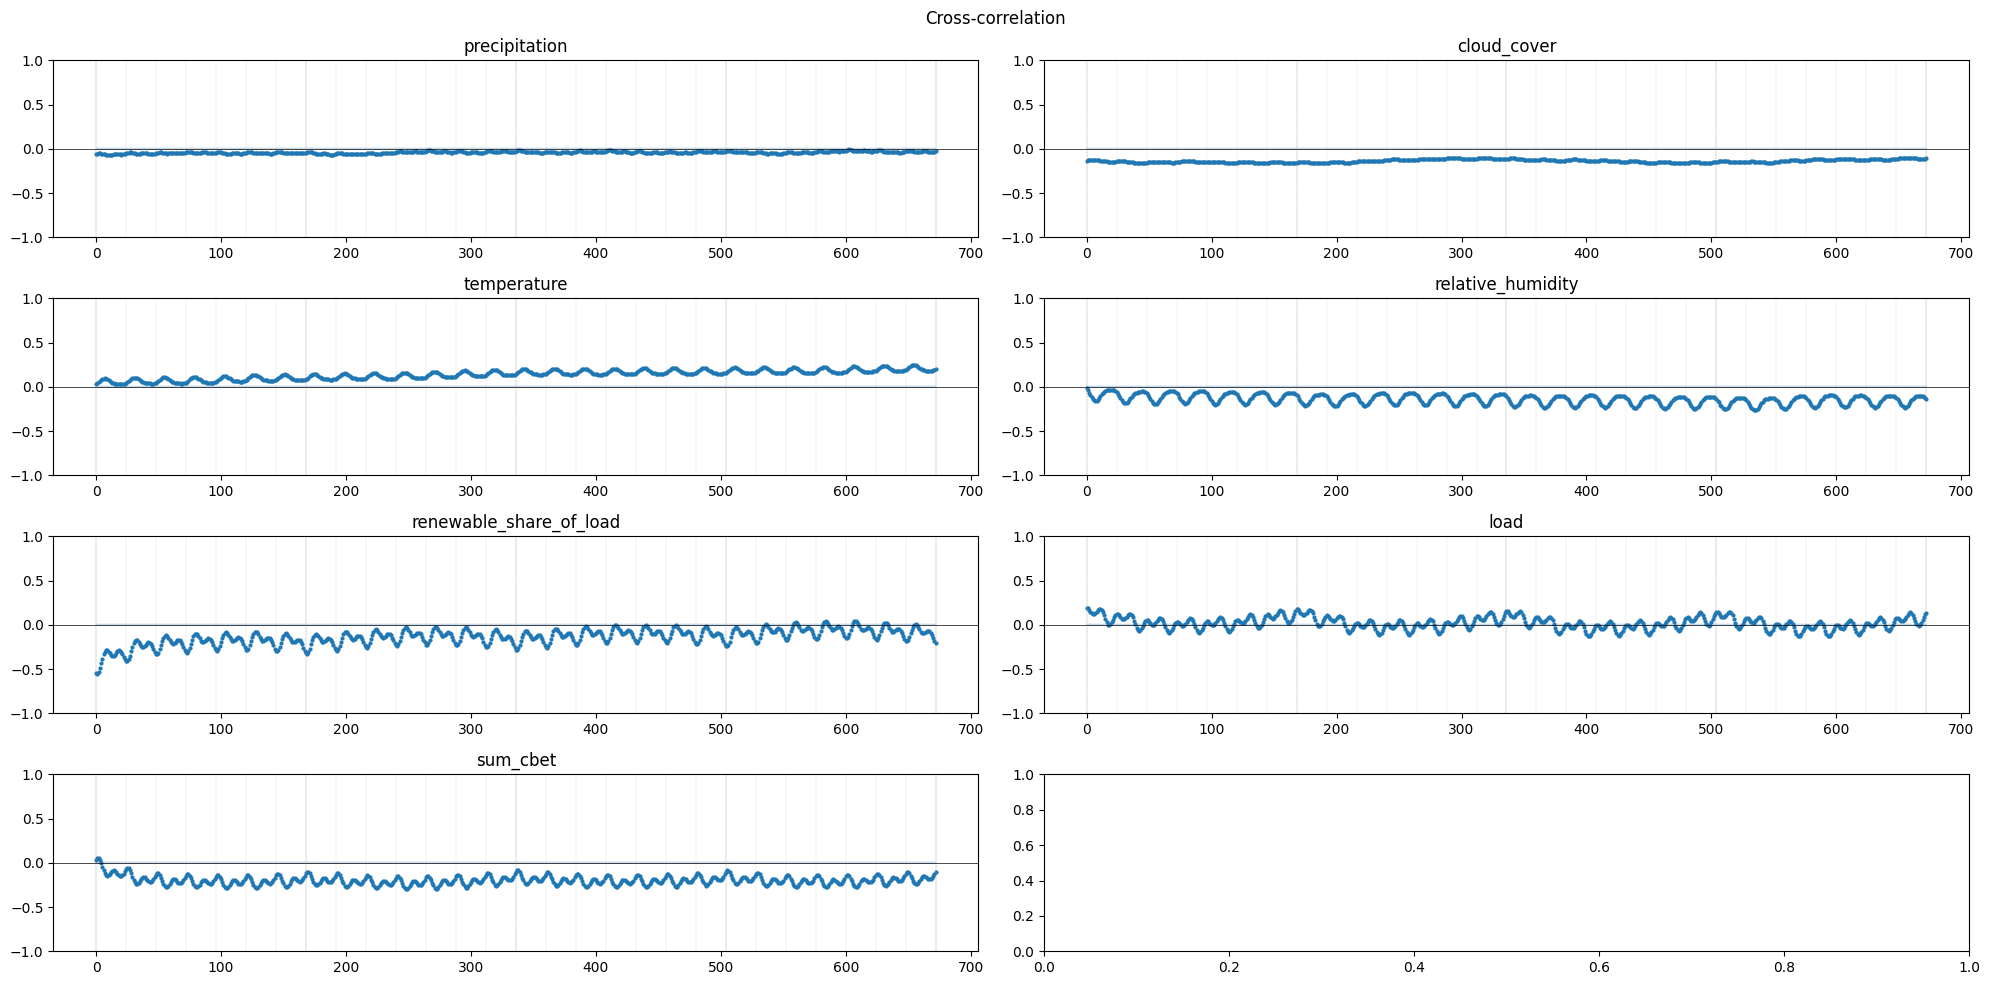

In [63]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 10))
axes = axes.flatten()

main_covar = [_ for _ in train_data.columns if _ not in ['datetime', 'price']]
for i, col in enumerate(main_covar):
    ax = axes[i]
    plot_ccf(x=train_data['price'], y=train_data[col], ax=ax, lags=24*7*4, use_vlines=False, markersize=2)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.vlines([_ for _ in range(0, 24*7*4+1, 24)], ymin=-1, ymax=1, color='gray', linewidth=0.2, linestyle=':')
    ax.vlines([_ for _ in range(0, 24*7*4+1, 24*7)], ymin=-1, ymax=1, color='gray', linewidth=0.2, linestyle='--')
    ax.set_title(col)

fig.suptitle('Cross-correlation')
fig.tight_layout()
plt.show()

In [56]:
train_data_00 = train_data.copy(deep=True)
for l in [_ for _ in range(12, 24)] + [_ for _ in range(24, 24*7, 24)] + [_ for _ in range(24*7, 24*7*4, 24*7)]:
    train_data_00.loc[:, f'price_l{l}'] = train_data_00.loc[:, 'price'].shift(l)
print(train_data_00.shape)
train_data_00.head()

(23673, 30)


,datetime,price,precipitation,cloud_cover,temperature,relative_humidity,renewable_share_of_load,load,sum_cbet,price_l12,price_l13,price_l14,price_l15,price_l16,price_l17,price_l18,price_l19,price_l20,price_l21,price_l22,price_l23,price_l24,price_l48,price_l72,price_l96,price_l120,price_l144,price_l168,price_l336,price_l504
26304,2022-01-01 00:00:00+00:00,41.33,0.025,87.50,11.425,85.50,86.5,41177.8,-8.397,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26305,2022-01-01 01:00:00+00:00,43.22,0.025,100.00,11.225,86.25,86.3,39669.8,-6.700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26306,2022-01-01 02:00:00+00:00,45.46,0.100,100.00,11.100,86.00,83.4,39448.7,-5.457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26307,2022-01-01 03:00:00+00:00,37.67,0.000,96.75,10.850,86.50,80.0,39112.1,-4.827,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26308,2022-01-01 04:00:00+00:00,39.70,0.000,100.00,10.775,86.00,78.7,38358.2,-4.569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
